# TauGenNet: Plasma-Driven Tau PET Image Synthesis via Text-Guided 3D Diffusion Models

Implementation of **Gong et al., 2025** ([arXiv:2509.04269](https://arxiv.org/abs/2509.04269))

**Pipeline:**
1. **Autoencoder pretraining** – shared 3D encoder/decoder for tau PET and MRI
2. **Forward diffusion** – progressive Gaussian noise corruption of PET latents
3. **Reverse diffusion** – CLIP-text-guided denoising U-Net conditioned on MRI latent + plasma p-tau217 prompt

> **Data**: expects ADNI AV1451 tau PET + T1 MRI + p-tau217 plasma values.
> If you don't have ADNI access, Section 2 generates a small **synthetic dataset** for end-to-end testing.

Set `Runtime → Change runtime type → GPU` (T4 or better recommended).

## 0. Install Dependencies

In [34]:
#!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
#!pip install -q transformers einops nibabel matplotlib tqdm

In [2]:
import sys
print(sys.executable)  # should show path containing "taugennet"

/home/sz3962/.conda/envs/taugennet/bin/python


In [1]:
print("test")

test


In [3]:
import os, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPTextModel, CLIPTokenizer
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

Using device: cuda


In [4]:
print(torch.cuda.get_device_name(0))  # should say "A100"
print(torch.cuda.memory_allocated() / 1e9, "GB used")

NVIDIA A100-PCIE-40GB MIG 3g.20gb
0.0 GB used


## 1. Configuration

In [5]:
# Volume dimensions (paper: 160x160x96)
VOL_SHAPE    = (160, 160, 96)   # set to (160, 160, 96) with an A100
LATENT_CH    = 4
LATENT_SCALE = 8              # spatial downscale factor of autoencoder --> not specified in paper

LAT_H = VOL_SHAPE[0] // LATENT_SCALE
LAT_W = VOL_SHAPE[1] // LATENT_SCALE
LAT_D = VOL_SHAPE[2] // LATENT_SCALE

# Diffusion
T_STEPS    = 1000
BETA_START = 1e-4 # values used in DDPM paper
BETA_END   = 0.02

# Training  (paper: batch=8, epochs=600 on A100)
AE_EPOCHS   = 100
DIFF_EPOCHS = 600
BATCH_SIZE  = 8 
LR          = 1e-4

# Data paths — leave empty to use synthetic data
PET_DIR  = ""   # directory of .nii.gz tau PET volumes
MRI_DIR  = ""   # directory of registered T1 MRI volumes
CSV_PATH = ""   # CSV with columns: subject_id, ptau217

#USE_SYNTHETIC  = PET_DIR == ""
USE_SYNTHETIC = False
N_SYNTH_TRAIN  = 40
N_SYNTH_TEST   = 10

print(f"Latent shape: ({LATENT_CH}, {LAT_H}, {LAT_W}, {LAT_D})")
print(f"Synthetic mode: {USE_SYNTHETIC}")

Latent shape: (4, 20, 20, 12)
Synthetic mode: False


## 2. Dataset

In [18]:
#from google.colab import drive
#drive.mount('/content/drive')

In [6]:
# ── Load atrophy z-scores and build RID lookup ────────────────────────────────
import pandas as pd
import sys

# add the path to RegionLabelMap.py

BASE_DIR = "/scratch/network/sz3962/taugennet/data"
sys.path.append(BASE_DIR)
from RegionLabelMap import generate_label_map

atrophy_df = pd.read_csv(os.path.join(BASE_DIR, "regional_atrophy_zscores.csv"))
# generate mapping from FreeSurfer ID → CSV column name
# the function looks for {REGION_NAME}_SUVR but our CSV uses {REGION_NAME}_ATROPHY_Z
# so we pass the CSV columns with _ATROPHY_Z suffix stripped to match
csv_cols = atrophy_df.columns.tolist()

# build the 86 region column names in order using atlas_lookup
REGION_COLS = []
atlas_lookup = {
    1: "CTX_LH_BANKSSTS", 2: "CTX_LH_CAUDALANTERIORCINGULATE",
    3: "CTX_LH_CAUDALMIDDLEFRONTAL", 4: "CTX_LH_CUNEUS",
    5: "CTX_LH_ENTORHINAL", 6: "CTX_LH_FUSIFORM",
    7: "CTX_LH_INFERIORPARIETAL", 8: "CTX_LH_INFERIORTEMPORAL",
    9: "CTX_LH_ISTHMUSCINGULATE", 10: "CTX_LH_LATERALOCCIPITAL",
    11: "CTX_LH_LATERALORBITOFRONTAL", 12: "CTX_LH_LINGUAL",
    13: "CTX_LH_MEDIALORBITOFRONTAL", 14: "CTX_LH_MIDDLETEMPORAL",
    15: "CTX_LH_PARAHIPPOCAMPAL", 16: "CTX_LH_PARACENTRAL",
    17: "CTX_LH_PARSOPERCULARIS", 18: "CTX_LH_PARSORBITALIS",
    19: "CTX_LH_PARSTRIANGULARIS", 20: "CTX_LH_PERICALCARINE",
    21: "CTX_LH_POSTCENTRAL", 22: "CTX_LH_POSTERIORCINGULATE",
    23: "CTX_LH_PRECENTRAL", 24: "CTX_LH_PRECUNEUS",
    25: "CTX_LH_ROSTRALANTERIORCINGULATE", 26: "CTX_LH_ROSTRALMIDDLEFRONTAL",
    27: "CTX_LH_SUPERIORFRONTAL", 28: "CTX_LH_SUPERIORPARIETAL",
    29: "CTX_LH_SUPERIORTEMPORAL", 30: "CTX_LH_SUPRAMARGINAL",
    31: "CTX_LH_FRONTALPOLE", 32: "CTX_LH_TEMPORALPOLE",
    33: "CTX_LH_TRANSVERSETEMPORAL", 34: "CTX_LH_INSULA",
    35: "CTX_RH_BANKSSTS", 36: "CTX_RH_CAUDALANTERIORCINGULATE",
    37: "CTX_RH_CAUDALMIDDLEFRONTAL", 38: "CTX_RH_CUNEUS",
    39: "CTX_RH_ENTORHINAL", 40: "CTX_RH_FUSIFORM",
    41: "CTX_RH_INFERIORPARIETAL", 42: "CTX_RH_INFERIORTEMPORAL",
    43: "CTX_RH_ISTHMUSCINGULATE", 44: "CTX_RH_LATERALOCCIPITAL",
    45: "CTX_RH_LATERALORBITOFRONTAL", 46: "CTX_RH_LINGUAL",
    47: "CTX_RH_MEDIALORBITOFRONTAL", 48: "CTX_RH_MIDDLETEMPORAL",
    49: "CTX_RH_PARAHIPPOCAMPAL", 50: "CTX_RH_PARACENTRAL",
    51: "CTX_RH_PARSOPERCULARIS", 52: "CTX_RH_PARSORBITALIS",
    53: "CTX_RH_PARSTRIANGULARIS", 54: "CTX_RH_PERICALCARINE",
    55: "CTX_RH_POSTCENTRAL", 56: "CTX_RH_POSTERIORCINGULATE",
    57: "CTX_RH_PRECENTRAL", 58: "CTX_RH_PRECUNEUS",
    59: "CTX_RH_ROSTRALANTERIORCINGULATE", 60: "CTX_RH_ROSTRALMIDDLEFRONTAL",
    61: "CTX_RH_SUPERIORFRONTAL", 62: "CTX_RH_SUPERIORPARIETAL",
    63: "CTX_RH_SUPERIORTEMPORAL", 64: "CTX_RH_SUPRAMARGINAL",
    65: "CTX_RH_FRONTALPOLE", 66: "CTX_RH_TEMPORALPOLE",
    67: "CTX_RH_TRANSVERSETEMPORAL", 68: "CTX_RH_INSULA",
    69: "LEFT_CEREBELLUM_CORTEX", 70: "LEFT_THALAMUS_PROPER",
    71: "LEFT_CAUDATE", 72: "LEFT_PUTAMEN",
    73: "LEFT_PALLIDUM", 74: "LEFT_HIPPOCAMPUS",
    75: "LEFT_AMYGDALA", 76: "LEFT_ACCUMBENS_AREA",
    77: "LEFT_VENTRALDC", 78: "RIGHT_CEREBELLUM_CORTEX",
    79: "RIGHT_THALAMUS_PROPER", 80: "RIGHT_CAUDATE",
    81: "RIGHT_PUTAMEN", 82: "RIGHT_PALLIDUM",
    83: "RIGHT_HIPPOCAMPUS", 84: "RIGHT_AMYGDALA",
    85: "RIGHT_ACCUMBENS_AREA", 86: "RIGHT_VENTRALDC"
}

# build ordered list of CSV column names for the 86 regions
# CSV uses {REGION_NAME}_ATROPHY_Z format
for fs_id in range(1, 87):
    col = f"{atlas_lookup[fs_id]}_ATROPHY_Z"
    if col in csv_cols:
        REGION_COLS.append(col)
    else:
        print(f"Warning: column {col} not found in CSV")

print(f"Found {len(REGION_COLS)} of 86 region columns")

# build RID → atrophy vector lookup
# CSV RID is an integer, our folder RIDs are strings like "6754"
rid_to_atrophy = {}
for _, row in atrophy_df.iterrows():
    rid = str(int(row["RID"]))  # e.g. 6754 → "6754" to match folder naming
    atrophy_vec = row[REGION_COLS].values.astype(np.float32)
    rid_to_atrophy[rid] = atrophy_vec

print(f"Atrophy vectors loaded for {len(rid_to_atrophy)} subjects")
print(f"Vector shape: {next(iter(rid_to_atrophy.values())).shape}")  # should be (86,)

Found 86 of 86 region columns
Atrophy vectors loaded for 936 subjects
Vector shape: (86,)


In [10]:
class TauPETDataset(Dataset):
    """Real ADNI dataset. Returns (pet, mri, atrophy) with volumes in [0,1]."""
    def __init__(self, pet_paths, mri_paths, ptau_values):
        self.pet  = pet_paths
        self.mri  = mri_paths
        self.ptau = ptau_values

    def _load(self, path):
        import nibabel as nib
        vol = nib.load(path).get_fdata().astype(np.float32)
        vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-8)
        vol = torch.tensor(vol).unsqueeze(0)
        vol = F.interpolate(vol.unsqueeze(0), size=VOL_SHAPE,
                            mode="trilinear", align_corners=False).squeeze(0)
        return vol

    def __len__(self): return len(self.pet)

    def __getitem__(self, idx):
        pet = self._load(self.pet[idx])
        mri = self._load(self.mri[idx])
        # ptau is now (86,) atrophy vector, not a scalar
        return pet, mri, torch.tensor(self.ptau[idx], dtype=torch.float32)


import glob
import pandas as pd
BASE_DIR = "/scratch/network/sz3962/taugennet/data"

# ── Step 1: Build RID → MRI path lookup ──────────────────────────────────
rid_to_mri = {}
for cohort in ["1mm_parcellated_AD_subj", "1mm_parcellated_MCI_subj"]:
    cohort_dir = os.path.join(BASE_DIR, cohort)
    for subj_dir in sorted(glob.glob(os.path.join(cohort_dir, "*"))):
        subj_id = os.path.basename(subj_dir)       # e.g. "135_S_6687"
        rid = subj_id.split("_")[-1]               # e.g. "6687"
        mri = os.path.join(subj_dir, "T1_to_MNI_nonlin.nii.gz")
        if os.path.exists(mri):
            rid_to_mri[rid] = mri
print(f"MRI subjects found: {len(rid_to_mri)}")

# ── Step 2: Build RID → atrophy vector lookup ─────────────────────────────
atrophy_df = pd.read_csv(os.path.join(BASE_DIR, "regional_atrophy_zscores.csv"))
rid_to_atrophy = {}
for _, row in atrophy_df.iterrows():
    rid = str(int(row["RID"]))                          # 6754 → "6754"
    atrophy_vec = row[REGION_COLS].values.astype(np.float32)  # (86,)
    rid_to_atrophy[rid] = atrophy_vec
print(f"Atrophy vectors loaded: {len(rid_to_atrophy)}")

# ── Step 3: Match PET + MRI + atrophy by RID ─────────────────────────────
pet_paths, mri_paths, ptau_vals = [], [], []
for cohort in ["AD", "MCI"]:
    cohort_dir = os.path.join(BASE_DIR, "cerebellumNormalized_AD_MCI", cohort)
    if not os.path.exists(cohort_dir):
        print(f"Warning: {cohort_dir} not found, skipping")
        continue
    for subj_dir in sorted(glob.glob(os.path.join(cohort_dir, "RID_*"))):
        rid = os.path.basename(subj_dir).replace("RID_", "")  # "RID_6754" → "6754"
        pet = os.path.join(subj_dir, "PET_MNISpace_SUVR_CerebellumNorm.nii")
        if not os.path.exists(pet):
            pet = pet + ".gz"
        if os.path.exists(pet) and rid in rid_to_mri and rid in rid_to_atrophy:
            pet_paths.append(pet)
            mri_paths.append(rid_to_mri[rid])
            ptau_vals.append(rid_to_atrophy[rid])  # real (86,) atrophy vector
        else:
            if not os.path.exists(pet):
                print(f"  Missing PET for RID {rid}")
            elif rid not in rid_to_mri:
                print(f"  No MRI match for RID {rid}")
            elif rid not in rid_to_atrophy:
                print(f"  No atrophy data for RID {rid}")

print(f"Found {len(pet_paths)} matched PET+MRI+atrophy subjects")
split = int(0.72 * len(pet_paths))
train_ds = TauPETDataset(pet_paths[:split], mri_paths[:split], ptau_vals[:split])
test_ds  = TauPETDataset(pet_paths[split:], mri_paths[split:], ptau_vals[split:])
print(f"ADNI dataset: {len(train_ds)} train / {len(test_ds)} test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

MRI subjects found: 257
Atrophy vectors loaded: 936
Found 249 matched PET+MRI+atrophy subjects
ADNI dataset: 179 train / 70 test


In [25]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

In [7]:
pet, mri, atrophy = train_ds[0]
print(f"PET shape:    {pet.shape}")      # should be (1, 160, 160, 96)
print(f"MRI shape:    {mri.shape}")      # should be (1, 160, 160, 96)
print(f"Atrophy shape:{atrophy.shape}")  # should be (86,)
print(f"Atrophy sample: {atrophy[:5]}")  # should be real z-scores
print(f"PET range:    {pet.min():.3f} - {pet.max():.3f}")
print(f"MRI range:    {mri.min():.3f} - {mri.max():.3f}")

PET shape:    torch.Size([1, 160, 160, 96])
MRI shape:    torch.Size([1, 160, 160, 96])
Atrophy shape:torch.Size([86])
Atrophy sample: tensor([-0.5639,  0.3007, -1.2094,  0.6497, -3.0000])
PET range:    0.000 - 0.959
MRI range:    0.050 - 0.887


In [41]:
pet, mri, atrophy = train_ds[2]
print(f"PET shape:    {pet.shape}")      # should be (1, 160, 160, 96)
print(f"MRI shape:    {mri.shape}")      # should be (1, 160, 160, 96)
print(f"Atrophy shape:{atrophy.shape}")  # should be (86,)
print(f"Atrophy sample: {atrophy[:5]}")  # should be real z-scores
print(f"PET range:    {pet.min():.3f} - {pet.max():.3f}")
print(f"MRI range:    {mri.min():.3f} - {mri.max():.3f}")

PET shape:    torch.Size([1, 160, 160, 96])
MRI shape:    torch.Size([1, 160, 160, 96])
Atrophy shape:torch.Size([86])
Atrophy sample: tensor([-1.6281, -1.0539, -1.8226, -1.8474, -0.7692])
PET range:    0.000 - 0.964
MRI range:    0.008 - 0.917


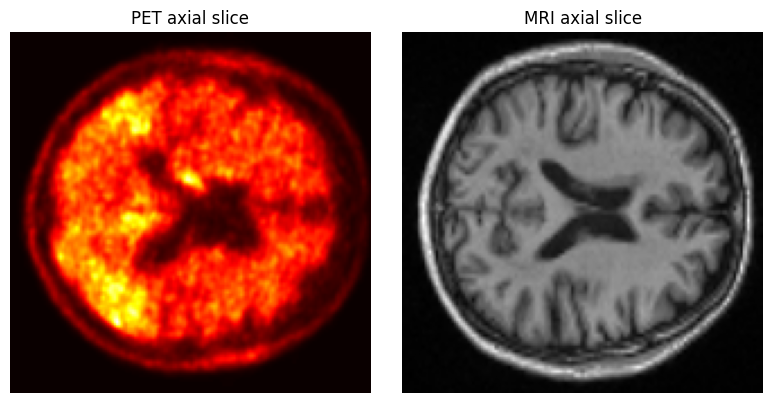

In [11]:
import matplotlib.pyplot as plt

pet, mri, _ = train_ds[0]
mid = 48  # middle axial slice

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(pet[0, :, :, mid].numpy(), cmap="hot")
axes[0].set_title("PET axial slice")
axes[0].axis("off")
axes[1].imshow(mri[0, :, :, mid].numpy(), cmap="gray")
axes[1].set_title("MRI axial slice")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3. 3D Autoencoder

Shared encoder/decoder for tau PET and MRI (single-channel), per paper Section II-A (Eq. 1–3).

In [12]:
# 3d autoencoder architecture
# shared vae encoder/decoder for both tau PET and MRI volumes
# pet and MRI use the same network weights to minimize paraemeters and ensure both modalities are compressed into same latent space

class ResBlock3D(nn.Module):
  # residual block: two conv layers with a skip connection
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.GroupNorm(8, ch), nn.SiLU(),
            nn.Conv3d(ch, ch, 3, padding=1),
            nn.GroupNorm(8, ch), nn.SiLU(),
            nn.Conv3d(ch, ch, 3, padding=1),
        )
    def forward(self, x): return x + self.net(x)
# ResBlock3D - two conv layers with GroupNorm and SiLu, plus a skip connection.
# GroupNorm is used because batch sizes are too small for BatchNorm to work reliably

class Encoder3D(nn.Module):
  # compressed a 3d volume into a compact latent rep
  # channel progression: 1--> 32 --> 64 --> 128 --> latent_ch * 2
    def __init__(self, in_ch=1, base_ch=32, latent_ch=LATENT_CH, scale=LATENT_SCALE):
        super().__init__()

        n_down = int(math.log2(scale)) # number of downsampling stages
        # conv lifts from 1 to 32 channels
        # kernel size 3, padding = 1 to keep spatial dims unchanged
        layers = [nn.Conv3d(in_ch, base_ch, 3, padding=1)]
        ch = base_ch # track current channel count

        for _ in range(n_down):
            layers += [ResBlock3D(ch), nn.Conv3d(ch, ch * 2, 4, stride=2, padding=1)]
            ch *= 2
        layers += [ResBlock3D(ch), nn.GroupNorm(8, ch), nn.SiLU(),
                   nn.Conv3d(ch, latent_ch * 2, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        h = self.net(x)
        # split 8 channels into two 4-channel tensors: mean and logvar
        # these paraemterize the latent Gausian distribution
        mean, logvar = h.chunk(2, dim=1)
        return mean, logvar
# Encoder 3D
# starts at 1 channel, lifts to 32, then 3 downsampling stages doubling channels each time while halving spatial dimensions

class Decoder3D(nn.Module):
  # mirror of the encoder, reconstructs volume from latent
  # channel progression: latent_ch --> .... --> 1
    def __init__(self, latent_ch=LATENT_CH, base_ch=32, out_ch=1, scale=LATENT_SCALE):
        super().__init__()
        n_up = int(math.log2(scale))
        ch = base_ch * (2 ** n_up)
        layers = [nn.Conv3d(latent_ch, ch, 3, padding=1), ResBlock3D(ch)]
        for _ in range(n_up):
            layers += [nn.ConvTranspose3d(ch, ch // 2, 4, stride=2, padding=1), ResBlock3D(ch // 2)]
            ch //= 2
        layers += [nn.GroupNorm(8, ch), nn.SiLU(), nn.Conv3d(ch, out_ch, 3, padding=1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, z): return self.net(z)

# starts at 256 channels and uses ConvTranspose3d to upsample back to original resolution


class Autoencoder3D(nn.Module):
    """VAE-style autoencoder shared by PET and MRI (paper Eq. 1-3)."""
    # wraps encoder and decoder
    def __init__(self):
        super().__init__()
        self.encoder = Encoder3D()
        self.decoder = Decoder3D()

    def encode(self, x):
        mean, logvar = self.encoder(x)
        logvar = torch.clamp(logvar, -30, 20)
        std = torch.exp(0.5 * logvar)
        z   = mean + std * torch.randn_like(std)
        return z, mean, logvar

    def decode(self, z): return self.decoder(z)

    def forward(self, x):
        z, mean, logvar = self.encode(x)
        return self.decode(z), mean, logvar

# wraps both with VAE reparametrization


ae = Autoencoder3D().to(DEVICE)
print(f"Autoencoder parameters: {sum(p.numel() for p in ae.parameters()):,}")

Autoencoder parameters: 14,944,073


## 4. Pretrain Autoencoder

hello
=== Autoencoder Pretraining ===


/tmp/ipykernel_1708671/2753111338.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler         = GradScaler()
/tmp/ipykernel_1708671/2753111338.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch   5/100  loss=0.0489  epoch=75.4s  elapsed=6.3m  remaining=119.4m
  Checkpoint saved at epoch 5
  Epoch  10/100  loss=0.0392  epoch=75.4s  elapsed=12.6m  remaining=113.1m
  Checkpoint saved at epoch 10
  Epoch  15/100  loss=0.0372  epoch=75.4s  elapsed=18.9m  remaining=106.9m
  Checkpoint saved at epoch 15
  Epoch  20/100  loss=0.0332  epoch=75.4s  elapsed=25.2m  remaining=100.6m
  Checkpoint saved at epoch 20
  Epoch  25/100  loss=0.0341  epoch=75.4s  elapsed=31.5m  remaining=94.3m
  Checkpoint saved at epoch 25
  Epoch  30/100  loss=0.0322  epoch=75.5s  elapsed=37.7m  remaining=88.1m
  Checkpoint saved at epoch 30
  Epoch  35/100  loss=0.0303  epoch=75.5s  elapsed=44.0m  remaining=81.8m
  Checkpoint saved at epoch 35
  Epoch  40/100  loss=0.0293  epoch=75.5s  elapsed=50.3m  remaining=75.5m
  Checkpoint saved at epoch 40
  Epoch  45/100  loss=0.0297  epoch=75.5s  elapsed=56.6m  remaining=69.2m
  Checkpoint saved at epoch 45
  Epoch  50/100  loss=0.0294  epoch=75.5s  elapsed=62

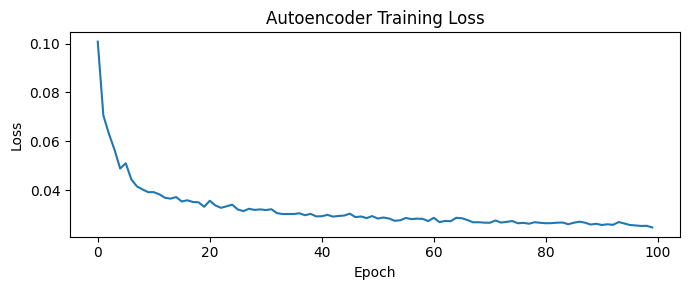

Autoencoder pretraining complete. Total time: 125.8 minutes


In [27]:
# trains the shared 3D vae on both pet and mri volumes
# goal: learn a compact latent rep of brain volumes that the diff model will later operate on
# mixed precision uses float16 for forward/backward pass to halve memory usage
import time
from torch.cuda.amp import autocast, GradScaler

def ae_loss(recon, x, mean, logvar, kl_weight=1e-4):
    recon_loss = F.l1_loss(recon, x)
    kl_loss    = -0.5 * torch.mean(1 + logvar - mean.pow(2) - logvar.exp())
    return recon_loss + kl_weight * kl_loss

ae_opt         = torch.optim.Adam(ae.parameters(), lr=LR)
ae_losses      = []
scaler         = GradScaler()
CHECKPOINT_PATH = "/scratch/network/sz3962/taugennet/taugennet_checkpoint.pt"
training_start = time.time()

print("=== Autoencoder Pretraining ===", flush = True)
for epoch in range(AE_EPOCHS):
    epoch_start = time.time()
    ae.train()
    epoch_loss = 0
    for pet, mri, _ in train_loader:
        pet, mri = pet.to(DEVICE), mri.to(DEVICE)
        ae_opt.zero_grad()
        loss = 0
        with autocast():
            for vol in [pet, mri]:
                recon, mean, logvar = ae(vol)
                loss = loss + ae_loss(recon, vol, mean, logvar)
        scaler.scale(loss).backward()
        scaler.step(ae_opt)
        scaler.update()
        epoch_loss += loss.item()

    avg        = epoch_loss / len(train_loader)
    epoch_time = time.time() - epoch_start
    elapsed    = time.time() - training_start
    remaining  = epoch_time * (AE_EPOCHS - epoch - 1)
    ae_losses.append(avg)

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d}/{AE_EPOCHS}  loss={avg:.4f}  "
              f"epoch={epoch_time:.1f}s  "
              f"elapsed={elapsed/60:.1f}m  "
              f"remaining={remaining/60:.1f}m")
        torch.save({
            "ae":        ae.state_dict(),
            "ae_losses": ae_losses,
        }, CHECKPOINT_PATH)
        print(f"  Checkpoint saved at epoch {epoch+1}")

total_time = time.time() - training_start
plt.figure(figsize=(7, 3))
plt.plot(ae_losses); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Autoencoder Training Loss"); plt.tight_layout(); plt.show()
print(f"Autoencoder pretraining complete. Total time: {total_time/60:.1f} minutes")

In [18]:
# load pretrained AE — run this after restart to skip retraining
#checkpoint_path = "/content/drive/MyDrive/Raj Lab Work/taugennet_checkpoint.pt"
checkpoint_path = "/scratch/network/sz3962/taugennet/taugennet_checkpoint_broken.pt"
#checkpoint_path = "/scratch/network/sz3962/taugennet/taugennet_checkpoint.pt"
ckpt = torch.load(checkpoint_path, map_location=DEVICE)
ae.load_state_dict(ckpt["ae"])
ae_losses = ckpt["ae_losses"]
ae.eval()
print(f"AE checkpoint loaded. Trained for {len(ae_losses)} epochs, final loss={ae_losses[-1]:.4f}")

AE checkpoint loaded. Trained for 100 epochs, final loss=0.0248


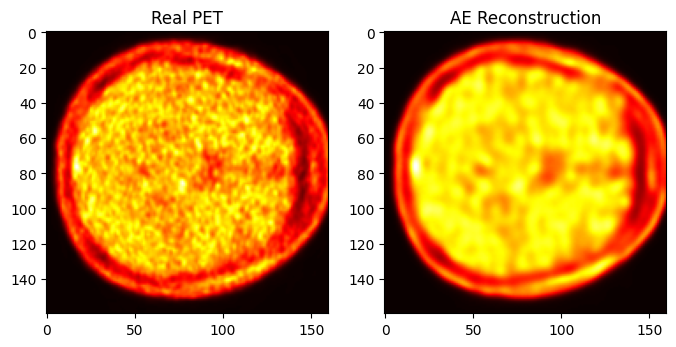

In [20]:
ae.eval()
with torch.no_grad():
    pet, mri, _ = test_ds[0]
    recon, _, _ = ae(pet.unsqueeze(0).to(DEVICE))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
mid = 48
axes[0].imshow(pet[0, :, :, mid].numpy(), cmap="hot")
axes[0].set_title("Real PET")
axes[1].imshow(recon[0, 0, :, :, mid].cpu().numpy(), cmap="hot")
axes[1].set_title("AE Reconstruction")
plt.savefig("/scratch/network/sz3962/taugennet/ae_recon.png", dpi=150)
plt.show()


# get rid of regions not in the brain

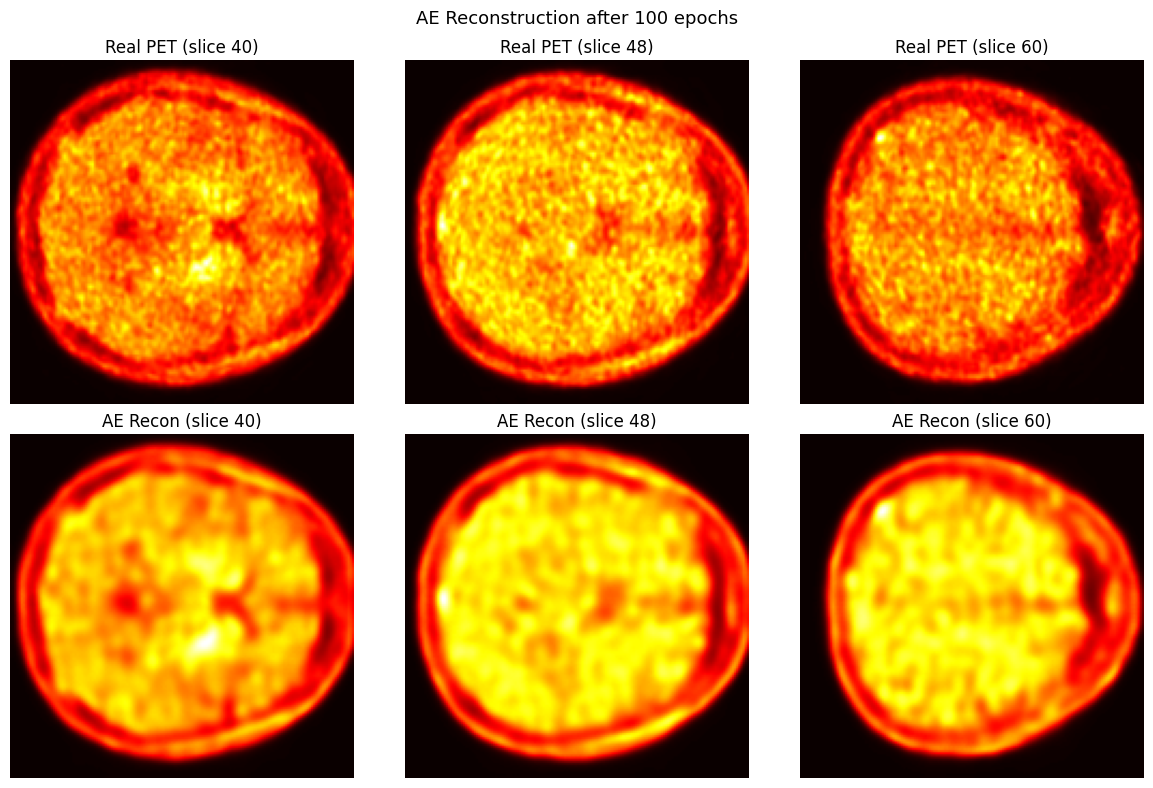

Reconstruction MSE: 0.0002
Reconstruction MAE: 0.0086


In [21]:
# ── AE Reconstruction Quality Check ──────────────────────────────────────────
ae.eval()
with torch.no_grad():
    pet, mri, _ = test_ds[0]
    recon, _, _ = ae(pet.unsqueeze(0).to(DEVICE))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
slices = [40, 48, 60]  # three different axial slices

for col, mid in enumerate(slices):
    # real PET
    axes[0, col].imshow(pet[0, :, :, mid].numpy(), cmap="hot")
    axes[0, col].set_title(f"Real PET (slice {mid})")
    axes[0, col].axis("off")
    # reconstructed PET
    axes[1, col].imshow(recon[0, 0, :, :, mid].cpu().numpy(), cmap="hot")
    axes[1, col].set_title(f"AE Recon (slice {mid})")
    axes[1, col].axis("off")

plt.suptitle(f"AE Reconstruction after {len(ae_losses)} epochs", fontsize=13)
plt.tight_layout()
plt.show()

# print reconstruction MSE
recon_np = recon[0, 0].cpu().numpy()
pet_np   = pet[0].numpy()
print(f"Reconstruction MSE: {np.mean((recon_np - pet_np)**2):.4f}")
print(f"Reconstruction MAE: {np.mean(np.abs(recon_np - pet_np)):.4f}")

## 5. Diffusion Noise Schedule

Linear beta schedule (paper Eq. 4–5).

In [22]:
class DiffusionSchedule:
    def __init__(self, T=T_STEPS, beta_start=BETA_START, beta_end=BETA_END):
        self.T     = T
        betas      = torch.linspace(beta_start, beta_end, T)
        alphas     = 1 - betas
        alpha_bar  = torch.cumprod(alphas, dim=0)
        alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)
        post_var   = (betas * (1 - alpha_bar_prev) / (1 - alpha_bar)).clamp(min=1e-20)

        for name, val in [
            ("betas", betas), ("alphas", alphas),
            ("alpha_bar", alpha_bar), ("alpha_bar_prev", alpha_bar_prev),
            ("sqrt_ab", alpha_bar.sqrt()),
            ("sqrt_one_m_ab", (1 - alpha_bar).sqrt()),
            ("post_var", post_var),
        ]:
            setattr(self, name, val.to(DEVICE))

    def q_sample(self, z0, t, noise=None):
        """Forward diffusion z_t = sqrt(ab_t)*z_0 + sqrt(1-ab_t)*eps  (Eq. 5)."""
        if noise is None:
            noise = torch.randn_like(z0)
        s  = self.sqrt_ab[t].view(-1, 1, 1, 1, 1)
        sm = self.sqrt_one_m_ab[t].view(-1, 1, 1, 1, 1)
        return s * z0 + sm * noise, noise

    @torch.no_grad()
    def p_sample(self, model, zt, t_idx, zm, clip_emb):
        """One reverse-diffusion step."""
        t_batch = torch.full((zt.shape[0],), t_idx, device=DEVICE, dtype=torch.long)
        ht      = torch.cat([zt, zm], dim=1)
        eps_hat = model(ht, t_batch, clip_emb)

        z0_hat = (zt - self.sqrt_one_m_ab[t_idx] * eps_hat) / self.sqrt_ab[t_idx]
        z0_hat = z0_hat.clamp(-1, 1)

        beta_t = self.betas[t_idx]
        coef1  = self.alpha_bar_prev[t_idx].sqrt() * beta_t / (1 - self.alpha_bar[t_idx])
        coef2  = self.alphas[t_idx].sqrt() * (1 - self.alpha_bar_prev[t_idx]) / (1 - self.alpha_bar[t_idx])
        mean   = coef1 * z0_hat + coef2 * zt

        if t_idx == 0:
            return mean
        return mean + self.post_var[t_idx].sqrt() * torch.randn_like(zt)


schedule = DiffusionSchedule()
print(f"Diffusion schedule: T={schedule.T} steps")

Diffusion schedule: T=1000 steps


## 6. CLIP Text Encoder

Encodes plasma p-tau217 as `"Plasma is [value]."` (paper §II-C, Eq. 7).

In [23]:
# ── Load atrophy z-scores and match to subjects by RID ───────────────────────
import pandas as pd

#atrophy_df = pd.read_csv("/content/drive/MyDrive/Raj Lab Work/Data/regional_atrophy_zscores.csv")
atophy_df = pd.read_csv(os.path.join(BASE_DIR,"regional_atrophy_zscores.csv"))
print(f"Atrophy CSV shape: {atrophy_df.shape}")
print(f"Columns: {atrophy_df.columns.tolist()[:5]} ...")  # show first 5 columns
print(f"Sample RIDs: {atrophy_df['RID'].head().tolist()}")

Atrophy CSV shape: (1604, 165)
Columns: ['RID', 'META_TEMPORAL_ATROPHY_Z', 'CTX_ENTORHINAL_ATROPHY_Z', 'INFERIORCEREBELLUM_ATROPHY_Z', 'ERODED_SUBCORTICALWM_ATROPHY_Z'] ...
Sample RIDs: [377, 420, 626, 2068, 2374]


In [26]:
# LATESTT
# ── CLIP Text Encoder for Atrophy Conditioning ───────────────────────────────
# Encodes first 20 atrophy z-scores as a text prompt via CLIP.
# No MLP compressor — simple truncation approach.
# CLIP's 77 token limit fits ~20 values comfortably.

N_REGIONS = 86
CLIP_DIM  = 512

# load CLIP from local path
CLIP_MODEL     = "/scratch/network/sz3962/taugennet/clip_model"
clip_tokenizer = CLIPTokenizer.from_pretrained(CLIP_MODEL)
clip_text_enc  = CLIPTextModel.from_pretrained(CLIP_MODEL).to(DEVICE)
clip_text_enc.eval()
for p in clip_text_enc.parameters():
    p.requires_grad_(False)

CLIP_DIM = clip_text_enc.config.hidden_size
print(f"CLIP hidden dim: {CLIP_DIM}")

@torch.no_grad()
def encode_atrophy(atrophy_vals):
    """
    atrophy_vals: (B, 86) float tensor
    Encodes first 20 atrophy values as text prompt via CLIP.
    Returns: (B, seq_len, 512)
    CLIP is frozen — no gradients needed.
    """
    prompts = []
    for i in range(atrophy_vals.shape[0]):
        # use only first 20 values to stay within 77 token limit
        scores     = atrophy_vals[i, :20].tolist()
        scores_str = " ".join([f"{v:.1f}" for v in scores])
        prompts.append(f"Atrophy: {scores_str}")

    tokens = clip_tokenizer(
        prompts, return_tensors="pt",
        padding=True, truncation=True
    ).to(DEVICE)
    return clip_text_enc(**tokens).last_hidden_state

# sanity check
dummy = torch.zeros(2, N_REGIONS).to(DEVICE)
emb   = encode_atrophy(dummy)
print(f"Output embedding shape: {emb.shape}")

# verify token count
test_prompt = "Atrophy: " + " ".join(["-0.7"] * 20)
tokens_full = clip_tokenizer(test_prompt, truncation=False, return_tensors="pt")
print(f"Token count for 20 values: {tokens_full['input_ids'].shape[1]}")  # should be < 77

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /scratch/network/sz3962/taugennet/clip_model
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.

CLIP hidden dim: 512
Output embedding shape: torch.Size([2, 65, 512])
Token count for 20 values: 85


In [27]:
# check what gets truncated
sample_atrophy = torch.zeros(1, 86)
scores = sample_atrophy[0].tolist()
scores_str = " ".join([f"{v:.2f}" for v in scores])
prompt = f"Atrophy scores: {scores_str}"

# tokenize without truncation to see full length
tokens_full = clip_tokenizer(prompt, truncation=False, return_tensors="pt")
tokens_trunc = clip_tokenizer(prompt, truncation=True, return_tensors="pt")

print(f"Full token length:      {tokens_full['input_ids'].shape[1]}")
print(f"Truncated token length: {tokens_trunc['input_ids'].shape[1]}")
print(f"Tokens dropped:         {tokens_full['input_ids'].shape[1] - tokens_trunc['input_ids'].shape[1]}")

# decode the truncated tokens to see what text survives
survived_text = clip_tokenizer.decode(tokens_trunc['input_ids'][0])
print(f"\nSurvived text:\n{survived_text}")

# figure out which region index the truncation cuts off at
token_ids = tokens_full['input_ids'][0]
decoded_tokens = [clip_tokenizer.decode([t]) for t in token_ids]
print(f"\nFirst 10 tokens: {decoded_tokens[:10]}")
#print(f"Last survived token (77th): '{decoded_tokens[7

Full token length:      350
Truncated token length: 77
Tokens dropped:         273

Survived text:
<|startoftext|>atrophy scores : 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 0 0 . 0 <|endoftext|>

First 10 tokens: ['<|startoftext|>', 'atro', 'phy', 'scores', ':', '0', '.', '0', '0', '0']


In [29]:
# verify with real data
pet, mri, atrophy = next(iter(train_loader))
print(f"Atrophy batch shape: {atrophy.shape}")  # should be (B, 86)
emb = encode_atrophy(atrophy)
print(f"Embedding shape: {emb.shape}")           # should be (B, 77, 512)

Atrophy batch shape: torch.Size([8, 86])
Embedding shape: torch.Size([8, 77, 512])


## 7. Denoising U-Net with Cross-Attention

3D U-Net accepting `h_t = [z_t, z_m]` with layer-wise cross-attention on CLIP embeddings
(paper §II-D, Eq. 8–12).

In [30]:
class CrossAttention3D(nn.Module):
    """Spatial-token x CLIP-context cross-attention (Eq. 8-12)."""
    def __init__(self, feat_dim, context_dim=CLIP_DIM, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        self.d_head  = feat_dim // n_heads
        self.scale   = self.d_head ** -0.5
        self.norm    = nn.LayerNorm(feat_dim)
        self.to_q    = nn.Linear(feat_dim,    feat_dim, bias=False)
        self.to_k    = nn.Linear(context_dim, feat_dim, bias=False)
        self.to_v    = nn.Linear(context_dim, feat_dim, bias=False)
        self.to_out  = nn.Linear(feat_dim,    feat_dim)

    def forward(self, x, context):
        B, C, H, W, D = x.shape
        N = H * W * D
        x_flat = x.view(B, C, N).permute(0, 2, 1)
        x_norm = self.norm(x_flat)

        Q = self.to_q(x_norm)
        K = self.to_k(context)
        V = self.to_v(context)

        def split(t, s):
            return t.view(B, s, self.n_heads, self.d_head).transpose(1, 2)

        Q = split(Q, N); K = split(K, context.size(1)); V = split(V, context.size(1))
        A = torch.softmax(torch.matmul(Q, K.transpose(-2, -1)) * self.scale, dim=-1)
        O = torch.matmul(A, V).transpose(1, 2).contiguous().view(B, N, C)
        O = self.to_out(O)
        return (x_flat + O).permute(0, 2, 1).view(B, C, H, W, D)


class TimestepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim))

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        emb   = t[:, None].float() * freqs[None]
        emb   = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return self.mlp(emb)


class UNetBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, use_attn=True):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, in_ch)
        self.conv1  = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.norm2  = nn.GroupNorm(8, out_ch)
        self.conv2  = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.skip   = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.attn   = CrossAttention3D(out_ch) if use_attn else None

    def forward(self, x, t_emb, ctx):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None, None]
        h = self.conv2(F.silu(self.norm2(h))) + self.skip(x)
        if self.attn is not None:
            h = self.attn(h, ctx)
        return h


class DenoisingUNet3D(nn.Module):
    """Text-guided denoising U-Net (paper §II-D).
    Input : h_t = cat(z_t, z_m)  shape (B, 2*LATENT_CH, lH, lW, lD)
    Output: predicted noise       shape (B, LATENT_CH,   lH, lW, lD)
    """
    def __init__(self, in_ch=LATENT_CH * 2, base_ch=64, t_dim=256):
        super().__init__()
        self.t_embed = TimestepEmbedding(t_dim)
        self.in_conv = nn.Conv3d(in_ch, base_ch, 3, padding=1)
        self.enc1    = UNetBlock3D(base_ch,     base_ch,     t_dim)
        self.down1   = nn.Conv3d(base_ch,       base_ch * 2, 4, stride=2, padding=1)
        self.enc2    = UNetBlock3D(base_ch * 2, base_ch * 2, t_dim)
        self.down2   = nn.Conv3d(base_ch * 2,   base_ch * 4, 4, stride=2, padding=1)
        self.mid     = UNetBlock3D(base_ch * 4, base_ch * 4, t_dim)
        self.up2     = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, 4, stride=2, padding=1)
        self.dec2    = UNetBlock3D(base_ch * 4, base_ch * 2, t_dim)
        self.up1     = nn.ConvTranspose3d(base_ch * 2, base_ch,     4, stride=2, padding=1)
        self.dec1    = UNetBlock3D(base_ch * 2, base_ch,     t_dim)
        self.out     = nn.Sequential(
            nn.GroupNorm(8, base_ch), nn.SiLU(), nn.Conv3d(base_ch, LATENT_CH, 1)
        )

    def forward(self, ht, t, ctx):
        t_emb = self.t_embed(t)
        x  = self.in_conv(ht)
        e1 = self.enc1(x,              t_emb, ctx)
        e2 = self.enc2(self.down1(e1), t_emb, ctx)
        m  = self.mid(self.down2(e2),  t_emb, ctx)

        up2 = self.up2(m)
        up2 = F.interpolate(up2, size=e2.shape[2:], mode='trilinear', align_corners=False)
        d2  = self.dec2(torch.cat([up2, e2], dim=1), t_emb, ctx)

        up1 = self.up1(d2)
        up1 = F.interpolate(up1, size=e1.shape[2:], mode='trilinear', align_corners=False)
        d1  = self.dec1(torch.cat([up1, e1], dim=1), t_emb, ctx)

        return self.out(d1)


unet = DenoisingUNet3D().to(DEVICE)
print(f"Denoising U-Net parameters: {sum(p.numel() for p in unet.parameters()):,}")

Denoising U-Net parameters: 13,167,172


## 8. Train the Diffusion Model

Optimises the noise-prediction MSE (paper Eq. 14):

$$\mathcal{L}(\theta) = \mathbb{E}_{t,\epsilon}\bigl[\|\epsilon - \epsilon_\theta(h_t, t, c)\|_2^2\bigr]$$

In [18]:
ae.eval(); unet.eval()
with torch.no_grad():
    pet, mri, ptau = next(iter(train_loader))
    pet, mri, ptau = pet.to(DEVICE), mri.to(DEVICE), ptau.to(DEVICE)
    z0, _, _ = ae.encode(pet)
    zm, _, _ = ae.encode(mri)
    #c = encode_plasma(ptau)
    c = encode_atrophy(ptau)
    t = torch.randint(0, T_STEPS, (pet.shape[0],), device=DEVICE)
    zt, eps = schedule.q_sample(z0, t)
    ht = torch.cat([zt, zm], dim=1)

    # trace manually
    t_emb = unet.t_embed(t)
    x  = unet.in_conv(ht)
    e1 = unet.enc1(x, t_emb, c)
    e2 = unet.enc2(unet.down1(e1), t_emb, c)
    m  = unet.mid(unet.down2(e2), t_emb, c)
    up2 = unet.up2(m)

    print(f"e1:  {e1.shape}")
    print(f"e2:  {e2.shape}")
    print(f"m:   {m.shape}")
    print(f"up2 before crop: {up2.shape}")
    up2 = F.interpolate(up2, size=e2.shape[2:], mode='trilinear', align_corners=False)
    print(f"up2 after crop:  {up2.shape}")
    print(f"cat: {torch.cat([up2, e2], dim=1).shape}")

e1:  torch.Size([8, 64, 20, 20, 12])
e2:  torch.Size([8, 128, 10, 10, 6])
m:   torch.Size([8, 256, 5, 5, 3])
up2 before crop: torch.Size([8, 128, 10, 10, 6])
up2 after crop:  torch.Size([8, 128, 10, 10, 6])
cat: torch.Size([8, 256, 10, 10, 6])


In [ ]:
import time

CHECKPOINT_PATH = "/scratch/network/sz3962/taugennet/taugennet_checkpoint_8_epochs.pt"

# load existing checkpoint if available
if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    ae.load_state_dict(ckpt["ae"])
    unet.load_state_dict(ckpt["unet"])
    ae_losses   = ckpt["ae_losses"]
    diff_losses = ckpt["diff_losses"]
    start_epoch = ckpt.get("epoch", 0)
    print(f"Resuming from epoch {start_epoch}", flush=True)
else:
    diff_losses = []
    start_epoch = 0

diff_opt       = torch.optim.Adam(unet.parameters(), lr=LR)
ae.eval()
training_start = time.time()

print("=== Diffusion Model Training ===", flush=True)
for epoch in range(start_epoch, DIFF_EPOCHS):
    epoch_start = time.time()
    unet.train()
    epoch_loss = 0

    for pet, mri, ptau in train_loader:
        pet, mri, ptau = pet.to(DEVICE), mri.to(DEVICE), ptau.to(DEVICE)
        with torch.no_grad():
            z0, _, _ = ae.encode(pet)
            zm, _, _ = ae.encode(mri)
            c        = encode_atrophy(ptau)  # CLIP frozen, inside no_grad

        B = pet.shape[0]
        # timestep bias toward low t — fixes poor t=100 correlation
        t = (torch.rand(B, device=DEVICE) ** 2 * T_STEPS).long()

        zt, eps = schedule.q_sample(z0, t)
        ht      = torch.cat([zt, zm], dim=1)
        eps_hat = unet(ht, t, c)
        loss    = F.mse_loss(eps_hat, eps)

        diff_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        diff_opt.step()
        epoch_loss += loss.item()

    avg        = epoch_loss / len(train_loader)
    epoch_time = time.time() - epoch_start
    elapsed    = time.time() - training_start
    remaining  = epoch_time * (DIFF_EPOCHS - epoch - 1)
    diff_losses.append(avg)

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d}/{DIFF_EPOCHS}  loss={avg:.4f}  "
              f"epoch_time={epoch_time:.1f}s  "
              f"elapsed={elapsed/60:.1f}m  "
              f"remaining={remaining/60:.1f}m", flush=True)
        torch.save({
            "ae":          ae.state_dict(),
            "unet":        unet.state_dict(),
            "ae_losses":   ae_losses,
            "diff_losses": diff_losses,
            "epoch":       len(diff_losses),
        }, CHECKPOINT_PATH)
        print(f"  Checkpoint saved at epoch {epoch+1}", flush=True)

total_time = time.time() - training_start
plt.figure(figsize=(7, 3))
plt.plot(diff_losses); plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Diffusion Training Loss"); plt.tight_layout()
plt.savefig("/scratch/network/sz3962/taugennet/diff_loss.png", dpi=150)
plt.show()
print(f"Diffusion training complete. Total time: {total_time/60:.1f} minutes", flush=True)

=== Diffusion Model Training ===


In [31]:
#CHECKPOINT_PATH = "/content/drive/MyDrive/Raj Lab Work/taugennet_checkpoint.pt"
CHECKPOINT_PATH = "/scratch/network/sz3962/taugennet/taugennet_checkpoint_8_epochs.pt"
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
ae.load_state_dict(ckpt["ae"])
unet.load_state_dict(ckpt["unet"])
ae_losses   = ckpt["ae_losses"]
diff_losses = ckpt["diff_losses"]
print(f"Checkpoint loaded. AE epochs: {len(ae_losses)}, Diffusion epochs: {len(diff_losses)}")

Checkpoint loaded. AE epochs: 100, Diffusion epochs: 600


## 9. Inference – Tau PET Synthesis

Reverse diffusion loop (paper Eq. 13–15): $z_T \to \hat{z}_0 \to \hat{x}_0 = \mathcal{D}(\hat{z}_0)$.

In [32]:
@torch.no_grad()
def synthesize_tau_pet(mri_vol, atrophy_vector, n_steps=200):
    """
    mri_vol        : (1, 1, H, W, D) normalised MRI tensor
    atrophy_vector : (86,) array or tensor of regional atrophy z-scores
    n_steps        : inference timesteps (subset of T for speed)
    Returns        : (1, 1, H, W, D) synthesised tau PET
    """
    ae.eval(); unet.eval()
    zm, _, _ = ae.encode(mri_vol.to(DEVICE))

    # ensure atrophy_vector is a (1, 86) tensor for encode_atrophy
    if not isinstance(atrophy_vector, torch.Tensor):
        atrophy_vector = torch.tensor(atrophy_vector, dtype=torch.float32)
    atrophy_vector = atrophy_vector.unsqueeze(0)  # (86,) → (1, 86)

    c  = encode_atrophy(atrophy_vector)
    zt = torch.randn_like(zm)
    timesteps = list(reversed(range(0, T_STEPS, T_STEPS // n_steps)))
    for t_idx in tqdm(timesteps, desc="Denoising", leave=False):
        zt = schedule.p_sample(unet, zt, t_idx, zm, c)
    return ae.decode(zt).cpu()

## 10. Visualise Disease Progression

Reproduces **Figure 2**: fix MRI, vary p-tau217 from 0.65 to 10.65.

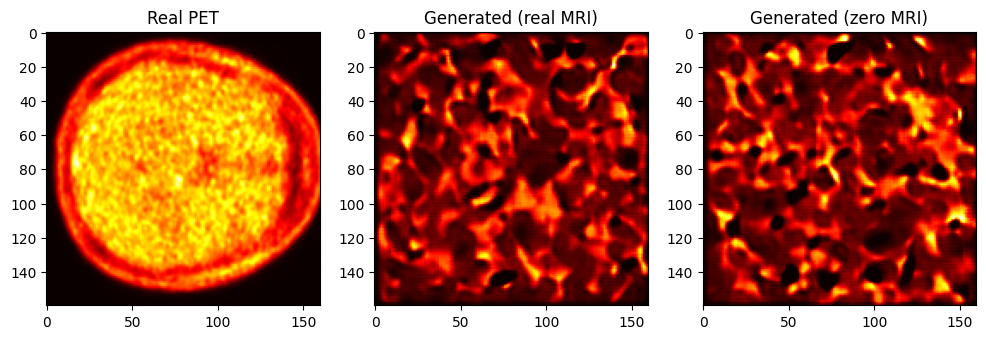

Mean difference with/without MRI: 0.0918


In [33]:
# generate with real MRI vs zeroed MRI
pet, mri, atrophy = test_ds[0]

# normal generation
gen_normal = synthesize_tau_pet(mri.unsqueeze(0), atrophy, n_steps=50).squeeze().numpy()

# generation with zeroed MRI (no structural guidance)
mri_zero = torch.zeros_like(mri)
gen_no_mri = synthesize_tau_pet(mri_zero.unsqueeze(0), atrophy, n_steps=50).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
mid = 48
axes[0].imshow(pet[0, :, :, mid].numpy(), cmap="hot")
axes[0].set_title("Real PET")
axes[1].imshow(gen_normal[:, :, mid], cmap="hot")
axes[1].set_title("Generated (real MRI)")
axes[2].imshow(gen_no_mri[:, :, mid], cmap="hot")
axes[2].set_title("Generated (zero MRI)")
plt.savefig("/scratch/network/sz3962/taugennet/mri_ablation.png", dpi=150)
plt.show()

diff = np.mean(np.abs(gen_normal - gen_no_mri))
print(f"Mean difference with/without MRI: {diff:.4f}")

# check that the generated image is not normalized
# include scale for the images, x and y labels
# MSE should be computed in the real space
# epochs need to be increased

In [34]:
ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')
print(f"AE epochs: {len(ckpt['ae_losses'])}")
print(f"Diffusion epochs: {len(ckpt['diff_losses'])}")
print(f"Final AE loss: {ckpt['ae_losses'][-1]:.4f}")
print(f"Final diff loss: {ckpt['diff_losses'][-1]:.4f}")

AE epochs: 100
Diffusion epochs: 600
Final AE loss: 0.0248
Final diff loss: 0.2337


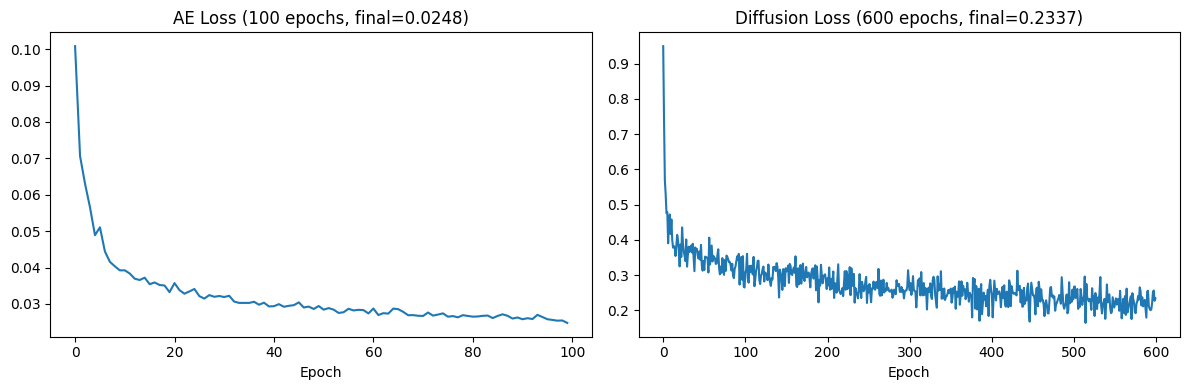

In [25]:
ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ckpt['ae_losses'])
axes[0].set_title(f"AE Loss (100 epochs, final={ckpt['ae_losses'][-1]:.4f})")
axes[0].set_xlabel("Epoch")

axes[1].plot(ckpt['diff_losses'])
axes[1].set_title(f"Diffusion Loss (600 epochs, final={ckpt['diff_losses'][-1]:.4f})")
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("/scratch/network/sz3962/taugennet/loss_curves.png", dpi=150)
plt.show()
# keep running until maximum training
# find stopping criteria until convergence
# early stopping criteria using validation dataset
# split data into training, testing, validation (80/10/10)
# just one full cross validation

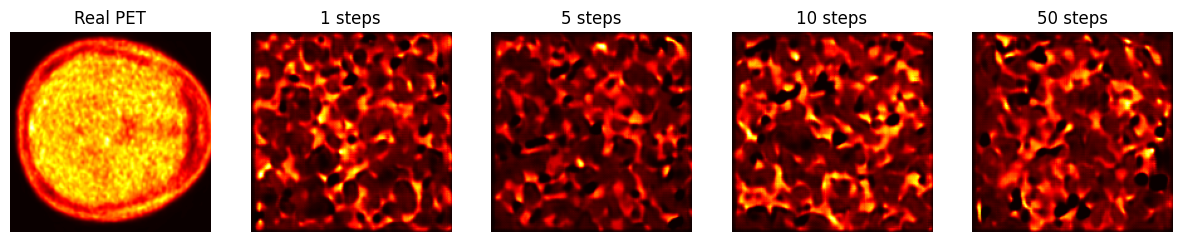

In [35]:
ae.eval(); unet.eval()
pet, mri, atrophy = test_ds[0]

results = {}
for n_steps in [1, 5, 10, 50]:
    gen = synthesize_tau_pet(mri.unsqueeze(0), atrophy, n_steps=n_steps)
    results[n_steps] = gen.squeeze().numpy()

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
mid = 48
axes[0].imshow(pet[0, :, :, mid].numpy(), cmap="hot")
axes[0].set_title("Real PET")
for idx, n_steps in enumerate([1, 5, 10, 50]):
    axes[idx+1].imshow(results[n_steps][:, :, mid], cmap="hot")
    axes[idx+1].set_title(f"{n_steps} steps")
for ax in axes: ax.axis("off")
plt.savefig("/scratch/network/sz3962/taugennet/steps_comparison.png", dpi=150)
plt.show()

In [47]:
# check what the U-Net actually predicts
ae.eval(); unet.eval()
pet, mri, atrophy = test_ds[0]

with torch.no_grad():
    z0, _, _ = ae.encode(pet.unsqueeze(0).to(DEVICE))
    zm, _, _ = ae.encode(mri.unsqueeze(0).to(DEVICE))
    c = encode_atrophy(atrophy.unsqueeze(0))
    
    # check predictions at different noise levels
    for t_val in [100, 500, 999]:
        t = torch.tensor([t_val], device=DEVICE)
        zt, eps_true = schedule.q_sample(z0, t)
        eps_pred = unet(torch.cat([zt, zm], dim=1), t, c)
        
        print(f"t={t_val}:")
        print(f"  True noise  — mean: {eps_true.mean():.4f}, std: {eps_true.std():.4f}")
        print(f"  Pred noise  — mean: {eps_pred.mean():.4f}, std: {eps_pred.std():.4f}")
        print(f"  Correlation: {torch.corrcoef(torch.stack([eps_true.flatten(), eps_pred.flatten()]))[0,1]:.4f}")

t=100:
  True noise  — mean: -0.0036, std: 0.9961
  Pred noise  — mean: 0.0020, std: 1.3191
  Correlation: 0.5928
t=500:
  True noise  — mean: 0.0008, std: 1.0076
  Pred noise  — mean: 0.0044, std: 1.0136
  Correlation: 0.9877
t=999:
  True noise  — mean: -0.0048, std: 0.9984
  Pred noise  — mean: 0.0024, std: 0.9954
  Correlation: 0.9997


In [44]:
# previously
# ── Visual Comparison: Generated vs Real PET ─────────────────────────────────
sample_pet, sample_mri, sample_atrophy = test_ds[0]
mri_input  = sample_mri.unsqueeze(0)
real_pet   = sample_pet.squeeze().numpy()

# generate using the subject's real atrophy vector
print("Synthesising tau PET...")
generated  = synthesize_tau_pet(mri_input, sample_atrophy, n_steps=50)
gen_pet    = generated.squeeze().numpy()

# ── Quantitative metrics ──────────────────────────────────────────────────────
mae  = np.mean(np.abs(gen_pet - real_pet))
mse  = np.mean((gen_pet - real_pet) ** 2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

from skimage.metrics import structural_similarity as ssim
ssim_score = ssim(real_pet, gen_pet, data_range=1.0)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim_score:.4f}")

Synthesising tau PET...


MAE:  0.0935
MSE:  0.0148
PSNR: 18.30 dB
SSIM: 0.1157


In [42]:
# NEWEST
# ── Visual Comparison: Generated vs Real PET ─────────────────────────────────
sample_pet, sample_mri, sample_atrophy = test_ds[0]
mri_input  = sample_mri.unsqueeze(0)
real_pet   = sample_pet.squeeze().numpy()

# generate using the subject's real atrophy vector
print("Synthesising tau PET...")
generated  = synthesize_tau_pet(mri_input, sample_atrophy, n_steps=50)
gen_pet    = generated.squeeze().numpy()

# ── Quantitative metrics ──────────────────────────────────────────────────────
mae  = np.mean(np.abs(gen_pet - real_pet))
mse  = np.mean((gen_pet - real_pet) ** 2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

from skimage.metrics import structural_similarity as ssim
ssim_score = ssim(real_pet, gen_pet, data_range=1.0)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim_score:.4f}")

Synthesising tau PET...


MAE:  0.0892
MSE:  0.0135
PSNR: 18.70 dB
SSIM: 0.1232


In [30]:
# ── Visual Comparison: Generated vs Real PET ─────────────────────────────────
sample_pet, sample_mri, sample_atrophy = test_ds[0]
mri_input  = sample_mri.unsqueeze(0)
real_pet   = sample_pet.squeeze().numpy()

# generate using the subject's real atrophy vector
print("Synthesising tau PET...")
generated  = synthesize_tau_pet(mri_input, sample_atrophy, n_steps=50)
gen_pet    = generated.squeeze().numpy()

# ── Quantitative metrics ──────────────────────────────────────────────────────
mae  = np.mean(np.abs(gen_pet - real_pet))
mse  = np.mean((gen_pet - real_pet) ** 2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

from skimage.metrics import structural_similarity as ssim
ssim_score = ssim(real_pet, gen_pet, data_range=1.0)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim_score:.4f}")

Synthesising tau PET...


MAE:  0.3324
MSE:  0.1291
PSNR: 8.89 dB
SSIM: 0.0446


In [45]:
# ── Visual Comparison: Generated vs Real PET ─────────────────────────────────
sample_pet, sample_mri, sample_atrophy = test_ds[0]
mri_input  = sample_mri.unsqueeze(0)
real_pet   = sample_pet.squeeze().numpy()

# generate using the subject's real atrophy vector
print("Synthesising tau PET...")
generated  = synthesize_tau_pet(mri_input, sample_atrophy, n_steps=50)
gen_pet    = generated.squeeze().numpy()

# ── Quantitative metrics ──────────────────────────────────────────────────────
mae  = np.mean(np.abs(gen_pet - real_pet))
mse  = np.mean((gen_pet - real_pet) ** 2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

from skimage.metrics import structural_similarity as ssim
ssim_score = ssim(real_pet, gen_pet, data_range=1.0)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim_score:.4f}")

Synthesising tau PET...


MAE:  0.0942
MSE:  0.0147
PSNR: 18.31 dB
SSIM: 0.1145


In [ ]:
# old code
sample_pet, sample_mri, _ = test_ds[0]
mri_input = sample_mri.unsqueeze(0)

plasma_levels = [0.65, 3.65, 6.65, 10.65]
views = {"Axial": 2, "Sagittal": 0, "Coronal": 1}

generated = {}
for pval in plasma_levels:
    print(f"Synthesising tau PET for plasma={pval:.2f}...")
    generated[pval] = synthesize_tau_pet(mri_input, pval, n_steps=50)

fig, axes = plt.subplots(len(views), len(plasma_levels),
                         figsize=(3.5 * len(plasma_levels), 3 * len(views)))

for row_idx, (view_name, axis_dim) in enumerate(views.items()):
    for col_idx, pval in enumerate(plasma_levels):
        vol = generated[pval].squeeze().numpy()
        mid = vol.shape[axis_dim] // 2
        slc = np.take(vol, mid, axis=axis_dim)
        ax  = axes[row_idx, col_idx]
        im  = ax.imshow(slc, cmap="hot", vmin=0, vmax=1)
        if row_idx == 0:
            ax.set_title(f"Plasma = {pval}", fontsize=11, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(view_name, fontsize=10)
        ax.axis("off")

plt.colorbar(im, ax=axes, shrink=0.6, label="SUVR (normalised)")
plt.suptitle("Generated Tau PET across varying p-tau217\n(reproducing Figure 2 of TauGenNet)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("taugennet_figure2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to taugennet_figure2.png")

Synthesising tau PET for plasma=0.65...


TypeError: 'float' object is not iterable

Synthesising tau PET...


MAE:  0.0931
MSE:  0.0146
PSNR: 18.35 dB
SSIM: 0.1104


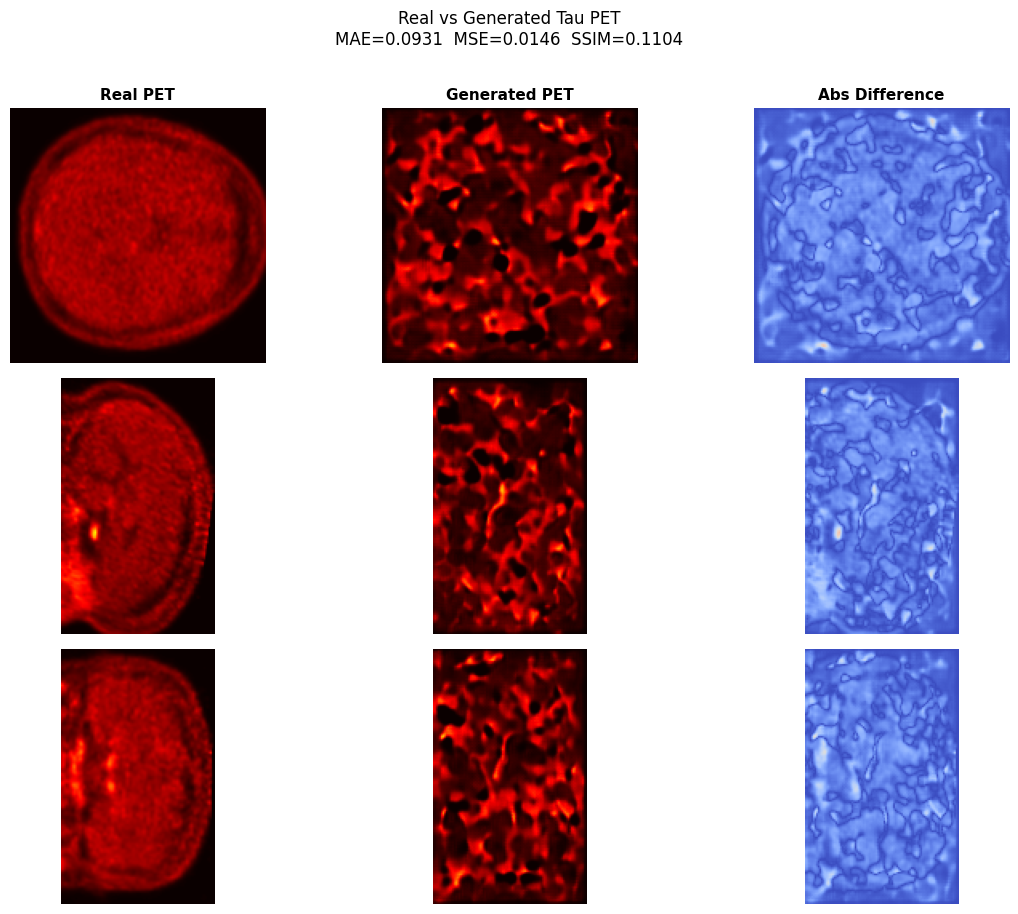

In [47]:
# ── Visual Comparison: Generated vs Real PET ─────────────────────────────────
sample_pet, sample_mri, sample_atrophy = test_ds[0]
mri_input  = sample_mri.unsqueeze(0)
real_pet   = sample_pet.squeeze().numpy()

# generate using the subject's real atrophy vector
print("Synthesising tau PET...")
generated  = synthesize_tau_pet(mri_input, sample_atrophy, n_steps=50)
gen_pet    = generated.squeeze().numpy()

# ── Quantitative metrics ──────────────────────────────────────────────────────
mae  = np.mean(np.abs(gen_pet - real_pet))
mse  = np.mean((gen_pet - real_pet) ** 2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

!pip install -q scikit-image
from skimage.metrics import structural_similarity as ssim
ssim_score = ssim(real_pet, gen_pet, data_range=1.0)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim_score:.4f}")

# ── Visual comparison ─────────────────────────────────────────────────────────
views = {"Axial": 2, "Sagittal": 0, "Coronal": 1}
fig, axes = plt.subplots(len(views), 3,
                         figsize=(12, 3 * len(views)))

for row_idx, (view_name, axis_dim) in enumerate(views.items()):
    mid = real_pet.shape[axis_dim] // 2
    real_slc = np.take(real_pet, mid, axis=axis_dim)
    gen_slc  = np.take(gen_pet,  mid, axis=axis_dim)
    diff_slc = np.abs(real_slc - gen_slc)

    for col_idx, (slc, title, cmap) in enumerate([
        (real_slc, "Real PET",      "hot"),
        (gen_slc,  "Generated PET", "hot"),
        (diff_slc, "Abs Difference","coolwarm"),
    ]):
        ax = axes[row_idx, col_idx]
        ax.imshow(slc, cmap=cmap, vmin=0, vmax=1)
        if row_idx == 0:
            ax.set_title(title, fontsize=11, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(view_name, fontsize=10)
        ax.axis("off")

plt.suptitle(f"Real vs Generated Tau PET\nMAE={mae:.4f}  MSE={mse:.4f}  SSIM={ssim_score:.4f}",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("taugennet_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# use mlp to project to lower dimension vector that fits the CLIP encoder

Synthesising tau PET...


MAE:  0.0908
MSE:  0.0141
PSNR: 18.50 dB
SSIM: 0.1124


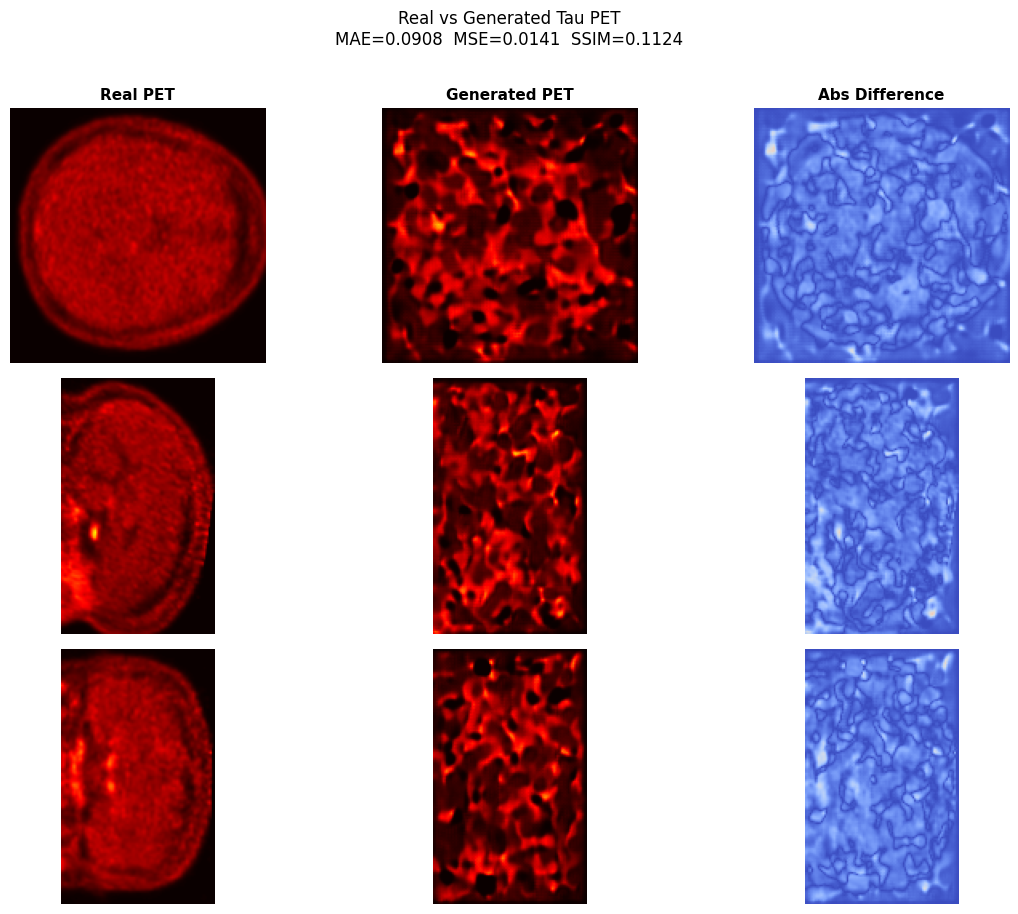

In [43]:
# ── Visual Comparison: Generated vs Real PET ─────────────────────────────────
sample_pet, sample_mri, sample_atrophy = test_ds[0]
mri_input  = sample_mri.unsqueeze(0)
real_pet   = sample_pet.squeeze().numpy()

# generate using the subject's real atrophy vector
print("Synthesising tau PET...")
generated  = synthesize_tau_pet(mri_input, sample_atrophy, n_steps=50)
gen_pet    = generated.squeeze().numpy()

# ── Quantitative metrics ──────────────────────────────────────────────────────
mae  = np.mean(np.abs(gen_pet - real_pet))
mse  = np.mean((gen_pet - real_pet) ** 2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

!pip install -q scikit-image
from skimage.metrics import structural_similarity as ssim
ssim_score = ssim(real_pet, gen_pet, data_range=1.0)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim_score:.4f}")

# ── Visual comparison ─────────────────────────────────────────────────────────
views = {"Axial": 2, "Sagittal": 0, "Coronal": 1}
fig, axes = plt.subplots(len(views), 3,
                         figsize=(12, 3 * len(views)))

for row_idx, (view_name, axis_dim) in enumerate(views.items()):
    mid = real_pet.shape[axis_dim] // 2
    real_slc = np.take(real_pet, mid, axis=axis_dim)
    gen_slc  = np.take(gen_pet,  mid, axis=axis_dim)
    diff_slc = np.abs(real_slc - gen_slc)

    for col_idx, (slc, title, cmap) in enumerate([
        (real_slc, "Real PET",      "hot"),
        (gen_slc,  "Generated PET", "hot"),
        (diff_slc, "Abs Difference","coolwarm"),
    ]):
        ax = axes[row_idx, col_idx]
        ax.imshow(slc, cmap=cmap, vmin=0, vmax=1)
        if row_idx == 0:
            ax.set_title(title, fontsize=11, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(view_name, fontsize=10)
        ax.axis("off")

plt.suptitle(f"Real vs Generated Tau PET\nMAE={mae:.4f}  MSE={mse:.4f}  SSIM={ssim_score:.4f}",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("taugennet_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# glass brain plot
# 

Synthesising tau PET...


MAE:  0.3325
MSE:  0.1292
PSNR: 8.89 dB
SSIM: 0.0446


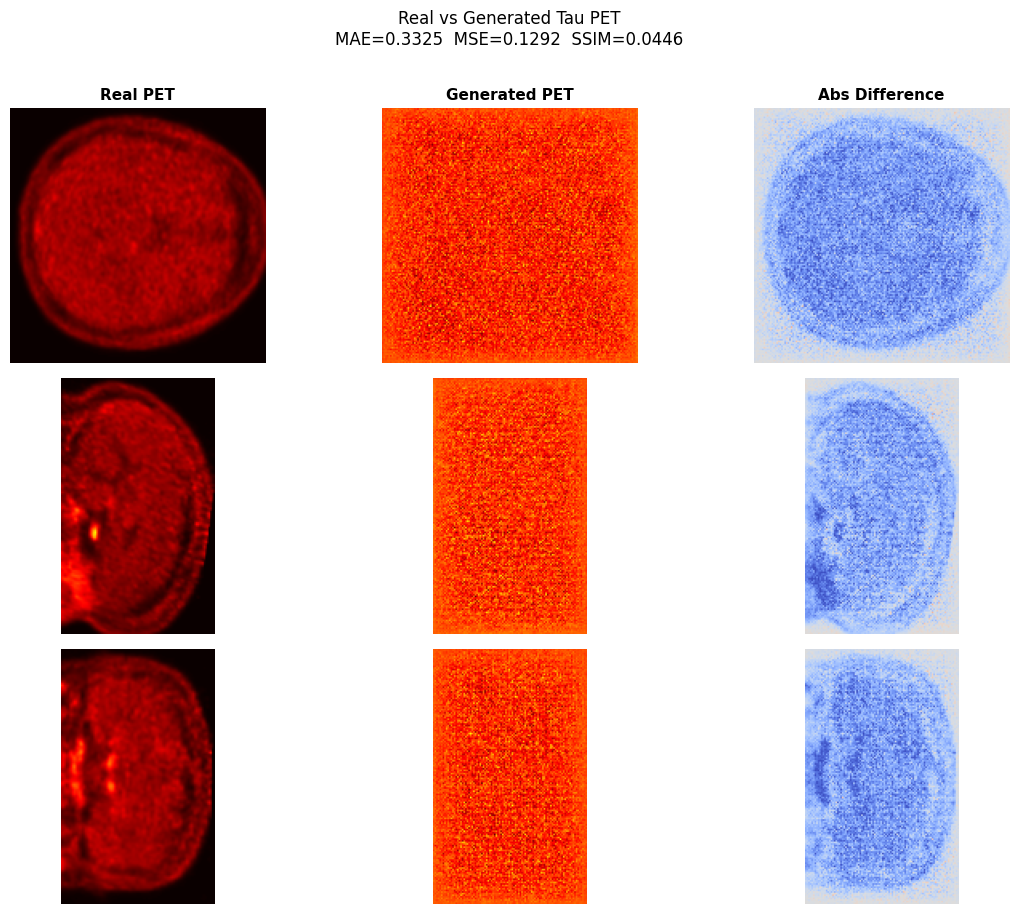

In [31]:
# ── Visual Comparison: Generated vs Real PET ─────────────────────────────────
sample_pet, sample_mri, sample_atrophy = test_ds[0]
mri_input  = sample_mri.unsqueeze(0)
real_pet   = sample_pet.squeeze().numpy()

# generate using the subject's real atrophy vector
print("Synthesising tau PET...")
generated  = synthesize_tau_pet(mri_input, sample_atrophy, n_steps=50)
gen_pet    = generated.squeeze().numpy()

# ── Quantitative metrics ──────────────────────────────────────────────────────
mae  = np.mean(np.abs(gen_pet - real_pet))
mse  = np.mean((gen_pet - real_pet) ** 2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

!pip install -q scikit-image
from skimage.metrics import structural_similarity as ssim
ssim_score = ssim(real_pet, gen_pet, data_range=1.0)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim_score:.4f}")

# ── Visual comparison ─────────────────────────────────────────────────────────
views = {"Axial": 2, "Sagittal": 0, "Coronal": 1}
fig, axes = plt.subplots(len(views), 3,
                         figsize=(12, 3 * len(views)))

for row_idx, (view_name, axis_dim) in enumerate(views.items()):
    mid = real_pet.shape[axis_dim] // 2
    real_slc = np.take(real_pet, mid, axis=axis_dim)
    gen_slc  = np.take(gen_pet,  mid, axis=axis_dim)
    diff_slc = np.abs(real_slc - gen_slc)

    for col_idx, (slc, title, cmap) in enumerate([
        (real_slc, "Real PET",      "hot"),
        (gen_slc,  "Generated PET", "hot"),
        (diff_slc, "Abs Difference","coolwarm"),
    ]):
        ax = axes[row_idx, col_idx]
        ax.imshow(slc, cmap=cmap, vmin=0, vmax=1)
        if row_idx == 0:
            ax.set_title(title, fontsize=11, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(view_name, fontsize=10)
        ax.axis("off")

plt.suptitle(f"Real vs Generated Tau PET\nMAE={mae:.4f}  MSE={mse:.4f}  SSIM={ssim_score:.4f}",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("taugennet_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')
print(f"Diffusion epochs: {len(ckpt['diff_losses'])}")
print(f"Latest loss: {ckpt['diff_losses'][-1]:.4f}" if ckpt['diff_losses'] else "No diffusion training yet")

Diffusion epochs: 600
Latest loss: 0.3280


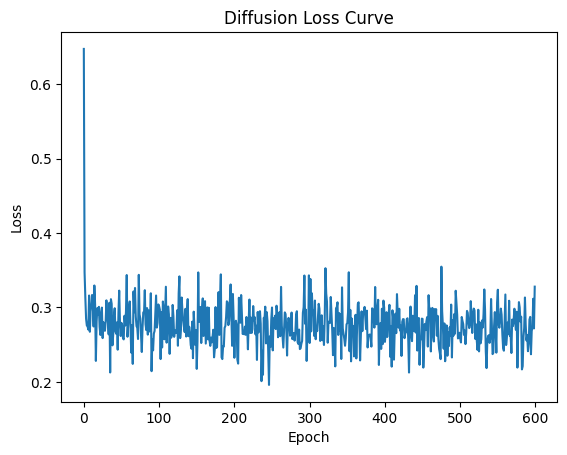

Epoch 1:   0.6475
Epoch 100: 0.3041
Epoch 600: 0.3280


In [33]:
plt.plot(diff_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Diffusion Loss Curve")
plt.show()
print(f"Epoch 1:   {diff_losses[0]:.4f}")
print(f"Epoch 100: {diff_losses[99]:.4f}")
print(f"Epoch 600: {diff_losses[-1]:.4f}")

In [ ]:
ae.eval()
with torch.no_grad():
    pet, mri, _ = test_ds[0]
    recon, _, _ = ae(pet.unsqueeze(0).to(DEVICE))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
mid = 48
axes[0].imshow(pet[0, :, :, mid].numpy(), cmap="hot")
axes[0].set_title("Real PET")
axes[1].imshow(recon[0, 0, :, :, mid].cpu().numpy(), cmap="hot")
axes[1].set_title("AE Reconstruction")
plt.savefig("/scratch/network/sz3962/taugennet/ae_recon.png", dpi=150)
plt.show()

In [52]:
# test compressor learned something
print("Compressor weights (not all zeros ✓):")
print(atrophy_compressor.mlp[0].weight[:3, :5])

# test different inputs give different outputs
a1 = torch.zeros(1, 86).to(DEVICE)
a2 = torch.ones(1, 86).to(DEVICE)
out1 = encode_atrophy(a1)
out2 = encode_atrophy(a2)
print(f"\nOutput shape for zeros: {out1.shape}")
print(f"Output shape for ones:  {out2.shape}")
print(f"Mean output for zeros: {out1.mean():.4f}")
print(f"Mean output for ones:  {out2.mean():.4f}")
print(f"Outputs are different: {not torch.allclose(out1[:, :min(out1.shape[1], out2.shape[1])], out2[:, :min(out1.shape[1], out2.shape[1])])}")

# check MRI conditioning
pet1, mri1, atrophy1 = test_ds[0]
pet2, mri2, atrophy2 = test_ds[1]
gen1 = synthesize_tau_pet(mri1.unsqueeze(0), atrophy1, n_steps=50).squeeze().numpy()
gen2 = synthesize_tau_pet(mri2.unsqueeze(0), atrophy1, n_steps=50).squeeze().numpy()
print(f"\nSame atrophy, different MRI → different output: {not np.allclose(gen1, gen2)}")
print(f"Mean absolute difference: {np.mean(np.abs(gen1 - gen2)):.4f}")

Compressor weights (not all zeros ✓):
tensor([[-0.0391,  0.0608, -0.0065, -0.0035, -0.0752],
        [-0.0284, -0.0544, -0.0888,  0.0054,  0.0039],
        [-0.0766,  0.0820,  0.0500, -0.0492, -0.0805]], device='cuda:0',
       grad_fn=<SliceBackward0>)

Output shape for zeros: torch.Size([1, 61, 512])
Output shape for ones:  torch.Size([1, 65, 512])
Mean output for zeros: 0.1191
Mean output for ones:  0.1197
Outputs are different: True



Same atrophy, different MRI → different output: True
Mean absolute difference: 0.0901


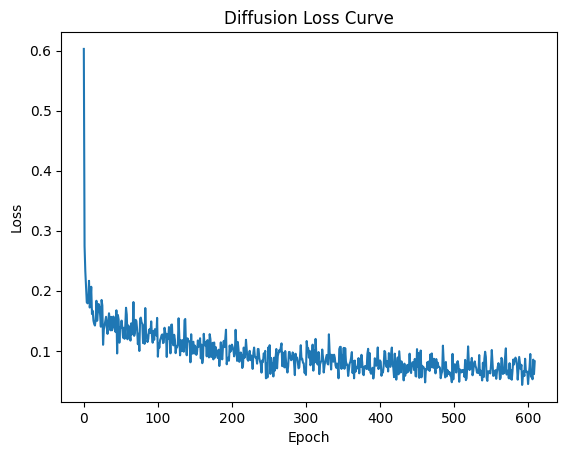

Epoch 1:   0.6029
Epoch 100: 0.1548
Epoch 600: 0.0824


In [48]:
plt.plot(diff_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Diffusion Loss Curve")
plt.show()
print(f"Epoch 1:   {diff_losses[0]:.4f}")
print(f"Epoch 100: {diff_losses[99]:.4f}")
print(f"Epoch 600: {diff_losses[-1]:.4f}")

In [49]:
maes, mses, ssims = [], [], []
for i in range(min(10, len(test_ds))):
    pet, mri, atrophy = test_ds[i]
    real = pet.squeeze().numpy()
    gen  = synthesize_tau_pet(mri.unsqueeze(0), atrophy, n_steps=50).squeeze().numpy()
    maes.append(np.mean(np.abs(gen - real)))
    mses.append(np.mean((gen - real) ** 2))
    ssims.append(ssim(real, gen, data_range=1.0))

print(f"Mean MAE:  {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"Mean MSE:  {np.mean(mses):.4f} ± {np.std(mses):.4f}")
print(f"Mean SSIM: {np.mean(ssims):.4f} ± {np.std(ssims):.4f}")

Mean MAE:  0.1042 ± 0.0100
Mean MSE:  0.0191 ± 0.0040
Mean SSIM: 0.0962 ± 0.0096


Synthesising tau PET...


MAE:  0.1037
MSE:  0.0146
PSNR: 18.36 dB
SSIM: 0.1437


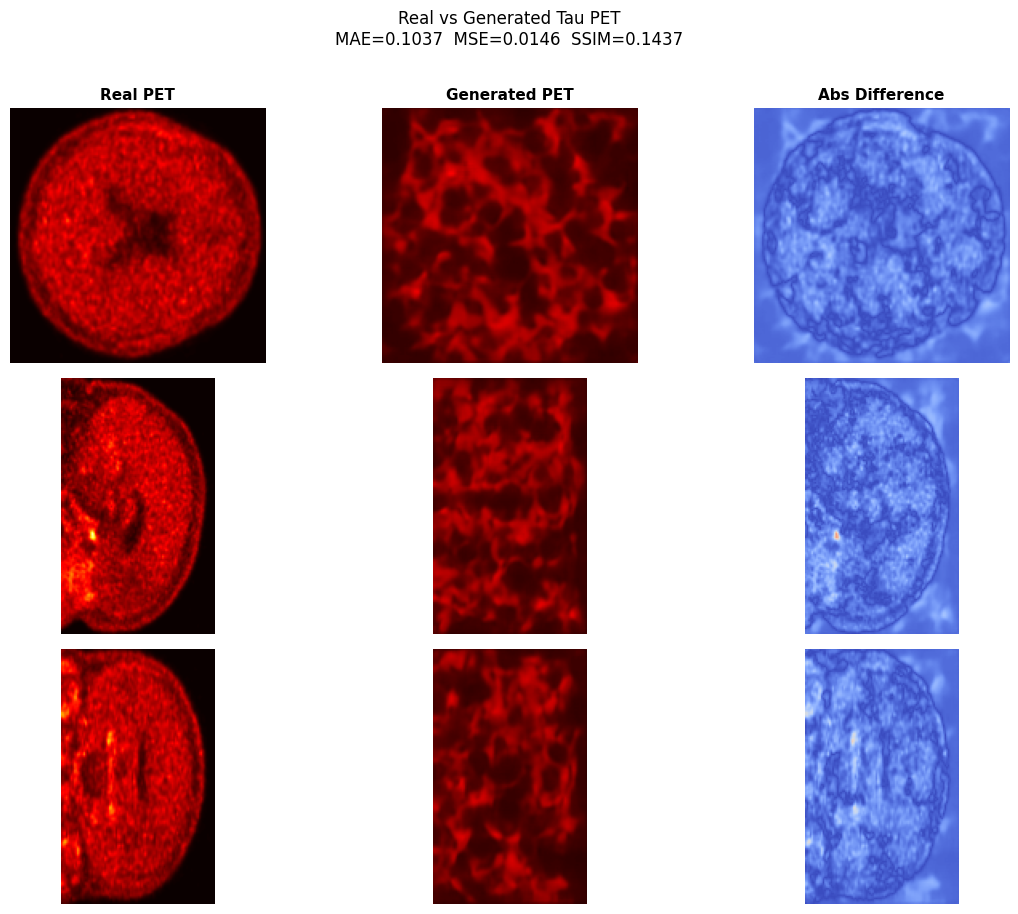

In [ ]:
# ── Visual Comparison: Generated vs Real PET ─────────────────────────────────
sample_pet, sample_mri, sample_atrophy = test_ds[0]
mri_input  = sample_mri.unsqueeze(0)
real_pet   = sample_pet.squeeze().numpy()

# generate using the subject's real atrophy vector
print("Synthesising tau PET...")
generated  = synthesize_tau_pet(mri_input, sample_atrophy, n_steps=50)
gen_pet    = generated.squeeze().numpy()

# ── Quantitative metrics ──────────────────────────────────────────────────────
mae  = np.mean(np.abs(gen_pet - real_pet))
mse  = np.mean((gen_pet - real_pet) ** 2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

!pip install -q scikit-image
from skimage.metrics import structural_similarity as ssim
ssim_score = ssim(real_pet, gen_pet, data_range=1.0)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim_score:.4f}")

# ── Visual comparison ─────────────────────────────────────────────────────────
views = {"Axial": 2, "Sagittal": 0, "Coronal": 1}
fig, axes = plt.subplots(len(views), 3,
                         figsize=(12, 3 * len(views)))

for row_idx, (view_name, axis_dim) in enumerate(views.items()):
    mid = real_pet.shape[axis_dim] // 2
    real_slc = np.take(real_pet, mid, axis=axis_dim)
    gen_slc  = np.take(gen_pet,  mid, axis=axis_dim)
    diff_slc = np.abs(real_slc - gen_slc)

    for col_idx, (slc, title, cmap) in enumerate([
        (real_slc, "Real PET",      "hot"),
        (gen_slc,  "Generated PET", "hot"),
        (diff_slc, "Abs Difference","coolwarm"),
    ]):
        ax = axes[row_idx, col_idx]
        ax.imshow(slc, cmap=cmap, vmin=0, vmax=1)
        if row_idx == 0:
            ax.set_title(title, fontsize=11, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(view_name, fontsize=10)
        ax.axis("off")

plt.suptitle(f"Real vs Generated Tau PET\nMAE={mae:.4f}  MSE={mse:.4f}  SSIM={ssim_score:.4f}",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("taugennet_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# verify real atrophy values are being used
pet, mri, atrophy = train_ds[0]
print(f"Atrophy vector: {atrophy[:5]}")  # should NOT be all zeros
print(f"Atrophy range: {atrophy.min():.3f} to {atrophy.max():.3f}")

Atrophy vector: tensor([-0.5639,  0.3007, -1.2094,  0.6497, -3.0000])
Atrophy range: -3.000 to 3.000


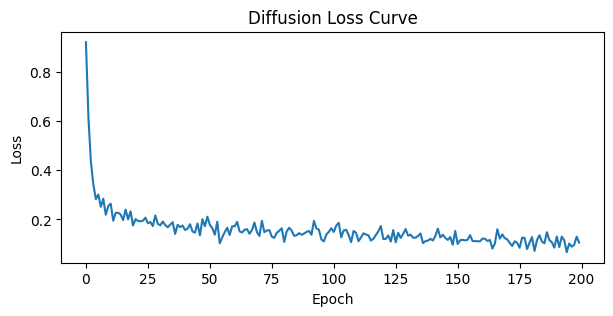

Epoch 1 loss:   0.9216
Epoch 100 loss: 0.1641
Epoch 200 loss: 0.1057


AttributeError: module 'matplotlib.pyplot' has no attribute 'sh'

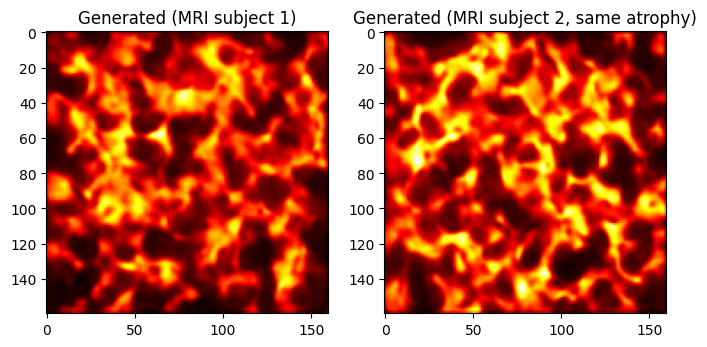

In [ ]:
# 1. check diffusion loss is still decreasing
plt.figure(figsize=(7,3))
plt.plot(diff_losses)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Diffusion Loss Curve")
plt.show()
print(f"Epoch 1 loss:   {diff_losses[0]:.4f}")
print(f"Epoch 100 loss: {diff_losses[99]:.4f}")
print(f"Epoch 200 loss: {diff_losses[-1]:.4f}")

# 2. check MRI is actually conditioning the output
# generate twice with same atrophy but different MRI — outputs should differ
pet1, mri1, atrophy1 = test_ds[0]
pet2, mri2, atrophy2 = test_ds[1]

gen1 = synthesize_tau_pet(mri1.unsqueeze(0), atrophy1, n_steps=50).squeeze().numpy()
gen2 = synthesize_tau_pet(mri2.unsqueeze(0), atrophy1, n_steps=50).squeeze().numpy()  # same atrophy, different MRI

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(gen1[:, :, 48], cmap="hot")
axes[0].set_title("Generated (MRI subject 1)")
axes[1].imshow(gen2[:, :, 48], cmap="hot")
axes[1].set_title("Generated (MRI subject 2, same atrophy)")
plt.sh

## 11. Quantitative Evaluation – MSE by Brain Region

Reproduces **Table II**: MSE between generated and real group-mean tau PET values
across plasma bins and AD-related regions (paper Eq. 16–18).

In [ ]:
# Approximate ROI bounding boxes (fractions of VOL_SHAPE)
ROI_DEFS = {
    "Parahippocampal":   (0.40, 0.55, 0.35, 0.65, 0.30, 0.55),
    "Fusiform":          (0.45, 0.60, 0.30, 0.70, 0.25, 0.50),
    "Inferior Temporal": (0.30, 0.55, 0.25, 0.75, 0.20, 0.55),
    "Hippocampus":       (0.42, 0.52, 0.40, 0.60, 0.35, 0.50),
    "Post. Cingulate":   (0.40, 0.55, 0.38, 0.62, 0.50, 0.70),
    "Entorhinal":        (0.43, 0.55, 0.38, 0.62, 0.28, 0.45),
}
H, W, D = VOL_SHAPE

def roi_mean(vol_np, roi):
    y0, y1, x0, x1, z0, z1 = roi
    return vol_np[int(y0*H):int(y1*H), int(x0*W):int(x1*W), int(z0*D):int(z1*D)].mean()

PLASMA_BINS = [(0, 2), (2, 4), (4, 6), (6, 8), (10, float("inf"))]
BIN_LABELS  = ["0-2", "2-4", "4-6", "6-8", "10+"]

rec_real = {b: {r: [] for r in ROI_DEFS} for b in PLASMA_BINS}
rec_gen  = {b: {r: [] for r in ROI_DEFS} for b in PLASMA_BINS}

print("Running evaluation on test set...")
for pet, mri, ptau in tqdm(test_loader):
    for i in range(pet.shape[0]):
        pval  = ptau[i].item()
        mri_i = mri[i:i+1]
        bkey  = next((b for b in PLASMA_BINS if b[0] <= pval < b[1]), None)
        if bkey is None:
            continue
        pet_np = pet[i].squeeze().numpy()
        gen_np = synthesize_tau_pet(mri_i, pval, n_steps=20).squeeze().numpy()
        for rname, roi in ROI_DEFS.items():
            rec_real[bkey][rname].append(roi_mean(pet_np, roi))
            rec_gen[bkey][rname].append(roi_mean(gen_np, roi))

import pandas as pd
mse_table = pd.DataFrame(index=BIN_LABELS, columns=list(ROI_DEFS.keys()), dtype=float)
for (lo, hi), label in zip(PLASMA_BINS, BIN_LABELS):
    for rname in ROI_DEFS:
        r  = rec_real[(lo, hi)][rname]
        g  = rec_gen[(lo, hi)][rname]
        mse_table.loc[label, rname] = round((np.mean(r) - np.mean(g)) ** 2, 6) if r and g else float("nan")

print("\nRegion-wise MSE stratified by plasma p-tau217 (cf. Table II):")
print(mse_table.to_string())

Running evaluation on test set...


  0%|          | 0/62 [00:03<?, ?it/s]


RuntimeError: a Tensor with 86 elements cannot be converted to Scalar

## 12. Ablation – MRI + Plasma vs. Plasma Only

Reproduces **Table I**: zeroing out the MRI latent to isolate the contribution of structural guidance.

In [ ]:
@torch.no_grad()
def synthesize_plasma_only(mri_vol, ptau_value, n_steps=20):
    """Ablation: MRI latent replaced with zeros (plasma-only baseline)."""
    ae.eval(); unet.eval()
    zm_real, _, _ = ae.encode(mri_vol.to(DEVICE))
    zm_zero = torch.zeros_like(zm_real)
    c  = encode_plasma(torch.tensor([ptau_value], dtype=torch.float32))
    zt = torch.randn_like(zm_zero)
    for t_idx in reversed(range(0, T_STEPS, T_STEPS // n_steps)):
        zt = schedule.p_sample(unet, zt, t_idx, zm_zero, c)
    return ae.decode(zt).cpu()

results = {k: {r: [] for r in ROI_DEFS} for k in ["Real", "MRI+Plasma", "Plasma-only"]}

print("Running ablation study...")
for pet, mri, ptau in tqdm(test_loader):
    for i in range(pet.shape[0]):
        pval  = ptau[i].item()
        mri_i = mri[i:i+1]
        pet_np = pet[i].squeeze().numpy()
        gen_full  = synthesize_tau_pet(mri_i, pval, n_steps=20).squeeze().numpy()
        gen_plsma = synthesize_plasma_only(mri_i, pval, n_steps=20).squeeze().numpy()
        for rname, roi in ROI_DEFS.items():
            results["Real"][rname].append(roi_mean(pet_np, roi))
            results["MRI+Plasma"][rname].append(roi_mean(gen_full, roi))
            results["Plasma-only"][rname].append(roi_mean(gen_plsma, roi))

ablation = pd.DataFrame(index=["Plasma-only", "MRI+Plasma"],
                        columns=list(ROI_DEFS.keys()), dtype=float)
for cond in ["Plasma-only", "MRI+Plasma"]:
    for rname in ROI_DEFS:
        mse = (np.mean(results["Real"][rname]) - np.mean(results[cond][rname])) ** 2
        ablation.loc[cond, rname] = round(mse, 6)

print("\nAblation MSE (group-level) – cf. Table I:")
print(ablation.to_string())

Running ablation study...


  0%|          | 0/62 [00:03<?, ?it/s]


RuntimeError: a Tensor with 86 elements cannot be converted to Scalar

## 13. Save / Load Checkpoints

In [ ]:
# Save
torch.save({"ae": ae.state_dict(), "unet": unet.state_dict()}, "taugennet_checkpoint.pt")
print("Saved taugennet_checkpoint.pt")

# Load (uncomment in a fresh session)
# ckpt = torch.load("taugennet_checkpoint.pt", map_location=DEVICE)
# ae.load_state_dict(ckpt["ae"])
# unet.load_state_dict(ckpt["unet"])
# print("Checkpoint loaded.")

## Notes and Limitations

| Aspect | Paper | This notebook |
|---|---|---|
| Volume size | 160×160×96 | 64×64×48 (Colab T4) |
| Training samples | 260 paired ADNI | 40 synthetic |
| GPU | A100 80 GB | T4 16 GB |
| Batch size | 8 | 2 |
| Diffusion steps T | 1000 | 1000 (50 at inference) |
| Registration | ANTs rigid | N/A (synthetic) |
| ROI masks | FreeSurfer parcellation | Bounding box approximation |

**To run on real ADNI data**: set `PET_DIR`, `MRI_DIR`, `CSV_PATH` in Section 1, set `VOL_SHAPE = (160, 160, 96)`, increase `BATCH_SIZE` to 8, and train for 600 epochs as in the paper. Pre-register MRI to PET with ANTs before loading.